In [24]:
# Import for OpenCV
import cv2

import numpy as np
import matplotlib.pyplot as plt 

CLAHE: Contrast Limited adapting Histogram Equalization

In [25]:
# Load the image and get it as greyscale
image = cv2.imread("./images/giraf2.jpg")

# Check if the image is loaded
if image is None:
    print(" Error: Can't load the image")
else:
    print("Image Loaded Successfully.")

# Convert from BGR to Grey
img_grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# Perform Histogram Equalization
equalized_img = cv2.equalizeHist(img_grey)


Image Loaded Successfully.


In [26]:
# Create Equalized image with RGB with YUV colors
image_yuv = cv2.cvtColor(image, cv2.COLOR_BGR2YUV)
image_yuv[:,:,0] = cv2.equalizeHist(image_yuv[:,:,0])

equalized_color_image = cv2.cvtColor(image_yuv, cv2.COLOR_YUV2BGR)
equalized_color_image_RGB = cv2.cvtColor(equalized_color_image, cv2.COLOR_BGR2RGB)


In [27]:
# 1. Create tiles , number of tiles
# cliplimit:      sets the threshold for the contrast limiting, to enhance contrast more by increasing it
# tileGrideSize:  Tiles size (pixels long, pixles wide)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4,4))

# Apply Clahe on the grey image
clahe_equlaized_image = clahe.apply(img_grey)


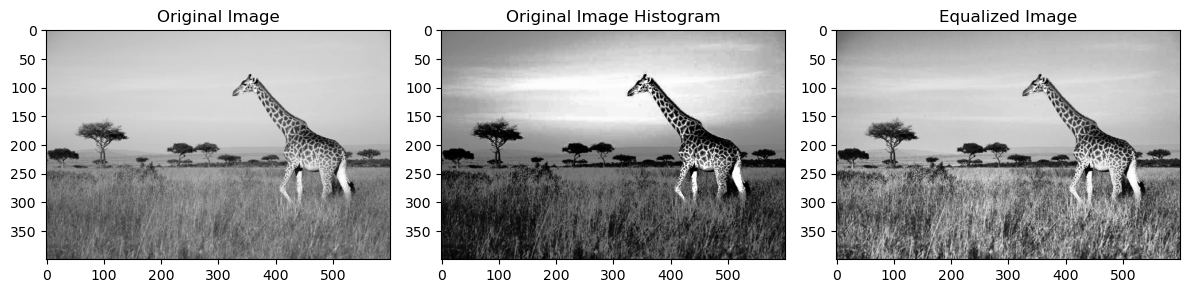

In [28]:
# Plots
# Show all resized images with each algorithm
plt.figure(figsize=(12,9))

# Show the original Image
plt.subplot(1,3,1)
plt.imshow(img_grey, cmap='grey')
plt.title("Original Image")

# Show the Equlaized Image 
plt.subplot(1,3,2)
plt.imshow(equalized_img, cmap='grey')
plt.title("Original Image Histogram")

# Show the  CLAHE Image
plt.subplot(1,3,3)
plt.imshow(clahe_equlaized_image, cmap='grey')
plt.title("Equalized Image")

plt.tight_layout()
plt.show()

You can see the Equlaized Histogram image is high contrast, but the problem is that it's with more noise in
While the CLAHE image, is a high contrast image,but it resolved noise issue, and no noise.

In [ ]:
# We cannot apply Histogram Equalization on grey image, so a technique should be used by YUV
# We first need to recreate our image into another color space like YUV
# Seperate channel for lightness, or brightness

# 1. Recreate the image in another color space like YUV
yuv_image= cv2.cvtColor(image, cv2.COLOR_BGR2YUV)
 
# 2. Apply the clahe on the first part of the yuv image which is Y-channel (Brightness part)
# the lightness is present in yuv image on the first y channel, so we put 0 in the first channel [third_ch, second_ch, first_ch]
yuv_image[:,:,0] = clahe.apply(yuv_image[:,:,0])

# 3. get the bgr image from the yuv image, and convert it to RGB image by end
yuv_image_bgr = cv2.cvtColor(yuv_image, cv2.COLOR_YUV2BGR)
yuv_image_rgb = cv2.cvtColor(yuv_image_bgr, cv2.COLOR_BGR2RGB)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 4. Re-Obtain the normal HE RGB image for comparison 
yuv_image_histogram= cv2.cvtColor(image, cv2.COLOR_BGR2YUV)
yuv_image_histogram[:,:,0] = cv2.equalizeHist(yuv_image_histogram[:,:,0])
equalized_color_image = cv2.cvtColor(yuv_image_histogram, cv2.COLOR_YUV2BGR)
equalized_color_image_RGB = cv2.cvtColor(equalized_color_image, cv2.COLOR_BGR2RGB)



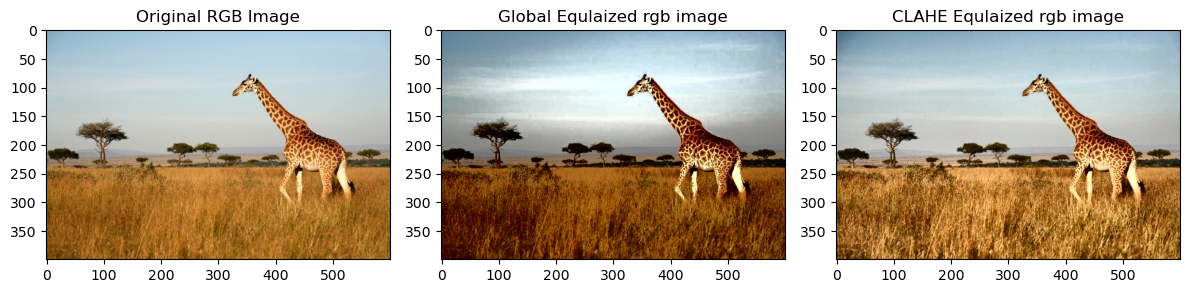

In [43]:
# Plots
# Show all resized images with each algorithm
plt.figure(figsize=(12,9))

# Show the original Image
plt.subplot(1,3,1)
plt.imshow(image_rgb, cmap='grey')
plt.title("Original RGB Image")

# Show the Equlaized RGB Image 
plt.subplot(1,3,2)
plt.imshow(equalized_color_image_RGB, cmap='grey')
plt.title("Global Equlaized rgb image")

# Show the CLAHE RGB Image 
plt.subplot(1,3,3)
plt.imshow(yuv_image_rgb, cmap='grey')
plt.title("CLAHE Equlaized rgb image")

plt.tight_layout()
plt.show()

* The colors looks natural in original, but lack of vibrancy 
* The CLAHE image, looks more vibrant and more contrast with some noise due to CLAHE , but not much noise compared to global Histogram Equlization.
* we just enhanced the luminance in the image, as we only apply the CLAHE on the y channel (brightness channel) leaving the uv channels as is without change.